In [1]:
# 工作目录锚点：不管 Jupyter 从哪里启动，都把工作目录切到仓库根
# 这样下面所有相对路径（data/…、charts/…）都按仓库根解析
%cd D:/yunnan-coffee


D:\yunnan-coffee


In [2]:
import pandas as pd
df = pd.read_csv('data/price_monthly.csv', encoding='utf-8')
df['date'] = pd.to_datetime(df['yr'].astype(str) + '-' + df['mth'].astype(str).str.zfill(2))


In [3]:
print(df.head())
print(df.dtypes)

     yr  mth market price_type  price       date
0  2023    1     昆明         综合   22.2 2023-01-01
1  2024    1     昆明         综合   29.2 2024-01-01
2  2025    1     云南         综合   52.9 2025-01-01
3  2025    2     云南         综合   63.8 2025-02-01
4  2025   10     普洱         商业   61.1 2025-10-01
yr                     int64
mth                    int64
market                   str
price_type               str
price                float64
date          datetime64[us]
dtype: object


In [4]:
commercial = df[df['price_type' ]== '商业']
special = df[df['price_type' ]== '精品']

In [5]:
print(len(commercial))
print(len(special))
print(commercial.head())
print(special.head())

8
6
      yr  mth market price_type  price       date
4   2025   10     普洱         商业  61.10 2025-10-01
5   2025   10     保山         商业  60.90 2025-10-01
6   2025   10     昆明         商业  61.30 2025-10-01
9   2025   11     云南         商业  60.79 2025-11-01
19  2026    2     云南         商业  52.60 2026-02-01
      yr  mth market price_type   price       date
7   2025   10     云南         精品  114.10 2025-10-01
8   2025   10     芒市         精品   70.42 2025-10-01
10  2025   11     云南         精品  142.47 2025-11-01
20  2026    2     云南         精品  142.97 2026-02-01
23  2026    5     云南         精品  146.81 2026-05-01


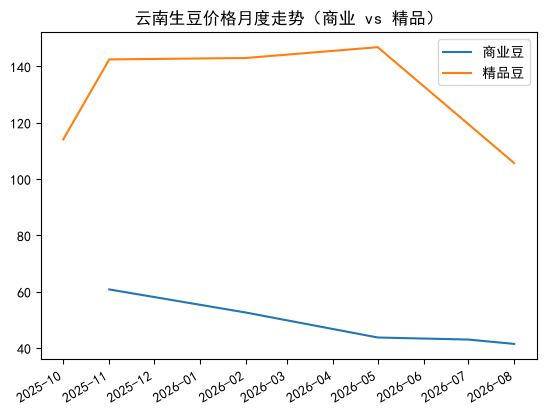

In [6]:
import matplotlib.pyplot as plt

commercial = commercial[commercial['market'] == '云南']
special = special[special['market'] == '云南']

# 排序——SQL 的 ORDER BY date，pandas 的方法名自己猜（sort_ 开头）
commercial = commercial.sort_values('date')
special    = special.sort_values('date')

# 中文显示（环境配置，这两行直接抄，不是我教的内容）：
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 画两条线：x 用 date 列，y 用 price 列，label 区分两条线
plt.plot(commercial['date'], commercial['price'], label='商业豆')
plt.plot(special['date'], special['price'], label='精品豆')
plt.gcf().autofmt_xdate()
plt.legend()
plt.title('云南生豆价格月度走势（商业 vs 精品）')
plt.savefig('charts/价格走势.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print(len(commercial),len(special))
print(commercial[['date','market','price']])
print(special[['date','market','price']])

5 5
         date market  price
9  2025-11-01     云南  60.79
19 2026-02-01     云南  52.60
22 2026-05-01     云南  43.73
24 2026-07-01     云南  43.00
25 2026-08-01     云南  41.45
         date market   price
7  2025-10-01     云南  114.10
10 2025-11-01     云南  142.47
20 2026-02-01     云南  142.97
23 2026-05-01     云南  146.81
26 2026-08-01     云南  105.66
